# Phase 2: Evolutionary Algorithm Optimization — `EA_Optimization.ipynb`

**Team 1 — NYC Taxi Trip Duration**

---

### What this notebook does

This notebook uses an **Evolutionary Algorithm (EA)** to find the best settings (called *hyperparameters*) for a neural network that predicts how long a taxi trip will take in New York City.

Think of it like this: instead of guessing which settings work best, we let a computer "evolve" better and better settings over many rounds — similar to how natural selection works in biology.

By the end, we compare the EA-tuned model against a simpler baseline to see if the extra effort was worth it.


---
## How to Run This Notebook

Follow these steps to run the notebook from start to finish:

1. **Open the notebook** on your JupyterHub environment (NRP or local machine).
2. **Make sure you have a GPU available.** The first code cell checks for this. If it says "Running on CPU," the notebook will still work but will be much slower.
3. **Run every cell in order, from top to bottom.** In Jupyter, you can do this by clicking `Kernel → Restart & Run All`.
4. **Do not skip cells or run them out of order.** Each cell depends on variables created by earlier cells.
5. **Output files** (plots, logs, model checkpoints) will be saved automatically to the `../artifacts/phase2/` folder.
6. **The full EA run may take 15–60 minutes** depending on your hardware. Be patient — progress prints after each generation.

> **Tip:** If you only want to check that the notebook works, you can temporarily reduce `GENERATIONS` to 2 and `POPULATION_SIZE` to 5 in the GA budget cell. Just remember to set them back before producing final results.


---
## Words We Use in This Notebook (Glossary)

Before reading the code, here are the key terms you will see throughout this notebook. Each one is explained in simple language.

| Term | What It Means |
|------|---------------|
| **Baseline model** | A simple model we use for comparison. If our fancy model cannot beat the baseline, it is not useful. |
| **Neural network** | A computer program loosely inspired by the brain. It learns patterns from data by adjusting internal numbers (weights). |
| **Hyperparameter** | A setting that we choose *before* training begins — like learning rate, dropout, or number of layers. The model cannot learn these on its own. |
| **Evolutionary Algorithm (EA)** | A search method inspired by biology. It creates a "population" of candidate solutions and evolves them over many rounds to find the best one. |
| **Genetic Algorithm (GA)** | A specific type of EA. It uses ideas from genetics — selection, crossover, and mutation — to improve candidates. |
| **Individual / Candidate** | One specific set of hyperparameters being tested. Think of it as one "contestant" in the competition. |
| **Population** | The full group of candidates being tested in one round. |
| **Generation** | One round of the genetic algorithm. Each generation evaluates the population, keeps the best, and creates new candidates. |
| **Fitness** | A score that says how good a candidate is. Here, fitness = validation R² (higher is better). |
| **Selection** | Picking the best candidates from the population to be "parents" of the next generation. |
| **Crossover** | Combining two parent candidates to create a new "child" candidate — like mixing traits from two parents. |
| **Mutation** | Randomly changing one or more settings in a candidate — like a small random tweak to explore new possibilities. |
| **Elitism** | Keeping the top few candidates unchanged into the next generation so we never lose the best solution found so far. |
| **Training set** | The data the model learns from (70% of all data). |
| **Validation set** | Data used to judge how good each candidate is *during* the search (15%). This guides the EA but is not the final test. |
| **Test set** | Data saved for the final check only (15%). It is touched exactly once at the very end to get an honest score. |
| **R² (R-squared)** | A score from 0 to 1 that measures how well the model explains the data. 1.0 = perfect; 0.0 = no better than guessing the average. Higher is better. |
| **MAPE (Mean Absolute Percentage Error)** | The average percentage the predictions are off by. Lower is better. |
| **RMSE (Root Mean Squared Error)** | A measure of prediction error in the same units as the target (seconds). Penalizes large errors more. Lower is better. |
| **MAE (Mean Absolute Error)** | The average absolute error in the same units as the target (seconds). Lower is better. |
| **Bootstrap confidence interval** | A statistical method that resamples the data many times to estimate how reliable a result is. If the interval does not include zero, the result is likely real, not luck. |
| **Log-transform** | Applying `log(x+1)` to squish large values closer together. This helps the model learn more evenly across short and long trips. |
| **Z-score scaling** | Subtracting the mean and dividing by the standard deviation so every feature has mean ≈ 0 and spread ≈ 1. This helps the model train faster. |


---
## Fair Evaluation Rules

To make sure our results are honest and trustworthy, we follow strict rules about how data is used:

| Data Split | What It Is Used For | When It Is Touched |
|---|---|---|
| **Training set (70%)** | Teaching the neural network | Every time a candidate is trained |
| **Validation set (15%)** | Scoring candidates during the EA search (fitness) | During EA evolution only |
| **Test set (15%)** | Getting the final, honest score | **Exactly once**, after the EA is completely finished |

**Why these rules matter:**
- If we used the test set to pick the best candidate, we would be "cheating" — the final score would look better than it really is.
- The validation set acts like a practice exam. The test set is the real exam, and you only get to take it once.
- No reshuffling or resplitting happens inside this notebook. The same split from Phase 1 is reused.


---
## GPU Preflight Check

> **What this does:** Checks whether a GPU (graphics processing unit) is available. GPUs make training much faster.  
> **Why it matters:** If no GPU is found, training will be very slow. You may want to switch to a GPU-enabled environment.


In [53]:
# 🔍 GPU Preflight Check (Run this BEFORE the EA cell)
import os
import torch

print("=== GPU PRECHECK ===")
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}:", torch.cuda.get_device_name(i))
    print("Current device:", torch.cuda.current_device())
else:
    print("Running on CPU — STOP if you expected GPU")

print(
    "NRP image hint:",
    os.environ.get("JUPYTER_IMAGE_SPEC")
    or os.environ.get("CONTAINER_IMAGE")
    or os.environ.get("JUPYTERHUB_IMAGE")
    or os.environ.get("IMAGE_NAME")
    or "UNKNOWN",
)
print("=== END PRECHECK ===")


=== GPU PRECHECK ===
CUDA available: True
GPU count: 2
GPU 0: NVIDIA GeForce GTX 1080
GPU 1: NVIDIA GeForce GTX 1080
Current device: 0
NRP image hint: gitlab-registry.nrp-nautilus.io/prp/jupyter-stack/prp-pytorch2:v1.0
=== END PRECHECK ===


## Cell 1 — Imports, Constants & Device

> **What this does:** Loads all the Python libraries we need and sets key constants that control the entire notebook.  
> **Why it matters:** Every cell below depends on these imports and constants being defined first.

### EA Data & Evaluation Protocol

**Data Splits:**
- **Train set:** Used ONLY for neural network training.
- **Validation set:** Used ONLY for EA fitness evaluation (picking the best candidate).
- **Test set:** Completely untouched during EA evolution. Used once at the very end.

**Split Policy:**
- Phase 1 official 70/15/15 split reused.
- Same random seed (`SEED = 42`). This keeps the shuffle the same every time so results are reproducible.
- No reshuffling or resplitting inside this notebook.

**Evaluation Discipline:**
- EA fitness is computed using Validation R² on the original scale (seconds).
- Validation MAPE is tracked as a secondary metric.
- Test metrics are computed exactly once after EA completes.


In [54]:
from pathlib import Path
import numpy as np
import pandas as pd

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ── Constants (identical to Phase 1) ──
SEED = 42
NROWS = 1_000_000
TARGET = "trip_duration"
CLIP_MIN = -2.0
CLIP_MAX = 13.0

DATA_PATH = Path("../data/train.csv")
DATA_URL = "https://github.com/DrAlzahraniProjects/csusb_spring26_cse5140_team1/releases/download/v1.0/train.csv"

ARTIFACTS_DIR = Path("../artifacts/phase2")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("EA_Optimization.ipynb — Phase 2")
print("=" * 60)
print(f"  SEED:      {SEED}")
print(f"  NROWS:     {NROWS:,}")
print(f"  TARGET:    {TARGET}")
print(f"  DATA_PATH: {DATA_PATH}")
print(f"  Device:    {device}")
print("=" * 60)


EA_Optimization.ipynb — Phase 2
  SEED:      42
  NROWS:     1,000,000
  TARGET:    trip_duration
  DATA_PATH: ../data/train.csv
  Device:    cuda


## Cell 2 — Deterministic Seeding

> **What this does:** Locks all random number generators to the same starting point.  
> **Why it matters:** This means every time you run the notebook, the random shuffles, weight initializations, and data splits will be identical. Without this, results would change slightly each run, making them harder to compare.

`SEED = 42` → This is an arbitrary but fixed number. Any number would work; 42 is a common convention. The important thing is that it stays the same.


In [55]:
import random

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
print(f"All RNGs seeded with {SEED}")


All RNGs seeded with 42


---
# Step 1.1 — Data Verification

Verify that Phase 2 uses the exact same dataset, shuffle, and splits as Phase 1.

> **What this does:** Downloads (if needed) and loads the NYC taxi trip dataset — 1 million rows of real taxi rides.  
> **Why it matters:** Both Phase 1 and Phase 2 must use the exact same data so comparisons are fair.

## Cell 3 — Load Dataset

Load first 1M rows and shuffle with `SEED=42`, identical to Phase 1.


In [56]:
if not DATA_PATH.exists():
    import urllib.request
    DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    print("Downloading dataset...")
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)
    print("Download complete.")
else:
    print("Dataset already exists at", DATA_PATH)

df = pd.read_csv(DATA_PATH, nrows=NROWS)
print(f"Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
print(f"Shuffled with seed={SEED}")
print(f"First 3 IDs after shuffle: {df['id'].head(3).tolist()}")


Dataset already exists at ../data/train.csv
Loaded: 1,000,000 rows, 11 columns
Shuffled with seed=42
First 3 IDs after shuffle: ['id3435429', 'id2267606', 'id3771460']


## Cell 4 — Train / Validation / Test Splits

> **What this does:** Splits the 1 million rows into three groups.  
> **Why it matters:** We need separate groups so training data does not contaminate our final evaluation.

Phase 2 reuses the official Phase 1 split:
- 70% Train (~700,000 rows) — the model learns from these
- 15% Validation (~150,000 rows) — the EA uses these to score candidates
- 15% Test (~150,000 rows) — saved for the final honest check

`random_state=SEED` → This ensures the split is identical every time.


In [57]:
# ── Official 70/15/15 split (reuse Phase 1 policy) ──
dev_df, test_df = train_test_split(df, test_size=0.15, random_state=SEED)
train_df, val_df = train_test_split(dev_df, test_size=(0.15/0.85), random_state=SEED)

print("Split sizes:")
print(f"  train_df: {len(train_df):>8,} rows  (70%)")
print(f"  val_df:   {len(val_df):>8,} rows  (15%)")
print(f"  test_df:  {len(test_df):>8,} rows  (15%)")
print(f"  total:    {len(train_df) + len(val_df) + len(test_df):>8,} rows")

# ── Assertions ──
assert len(train_df) + len(val_df) + len(test_df) == NROWS, "Row count mismatch!"
assert abs(len(train_df) - 700_000) < 1000, f"Train expected ~700k, got {len(train_df)}"
assert abs(len(val_df) - 150_000) < 1000,   f"Val expected ~150k, got {len(val_df)}"
assert abs(len(test_df) - 150_000) < 1000,  f"Test expected ~150k, got {len(test_df)}"

print("\n✅ All split assertions passed — 70/15/15 verified")

Split sizes:
  train_df:  700,000 rows  (70%)
  val_df:    150,000 rows  (15%)
  test_df:   150,000 rows  (15%)
  total:    1,000,000 rows

✅ All split assertions passed — 70/15/15 verified


## Cell 6 — Step 1.1 Summary

> **What this does:** Prints a verification table confirming the data matches Phase 1.  
> **Why it matters:** If anything is different (wrong row count, wrong seed), this will catch it before we waste time training.


In [58]:
verification_summary = pd.DataFrame([
    {"Check": "Dataset rows loaded", "Expected": "1,000,000", "Actual": f"{len(df):,}", "Status": "✅"},
    {"Check": "Random seed", "Expected": "42", "Actual": str(SEED), "Status": "✅"},

    {"Check": "Train rows", "Expected": "~700,000", "Actual": f"{len(train_df):,}", "Status": "✅"},
    {"Check": "Validation rows", "Expected": "~150,000", "Actual": f"{len(val_df):,}", "Status": "✅"},
    {"Check": "Test rows", "Expected": "~150,000", "Actual": f"{len(test_df):,}", "Status": "✅"},

    {"Check": "Total rows", "Expected": "1,000,000",
     "Actual": f"{len(train_df)+len(val_df)+len(test_df):,}", "Status": "✅"},

    {"Check": "No re-splitting", "Expected": "Single split only",
     "Actual": f"random_state={SEED}", "Status": "✅"},
])

print("=" * 60)
print("STEP 1.1 — DATA VERIFICATION RESULTS (70/15/15)")
print("=" * 60)
print(verification_summary.to_string(index=False))
print("\n✅ Step 1.1 complete — dataset and 70/15/15 splits verified")

STEP 1.1 — DATA VERIFICATION RESULTS (70/15/15)
              Check          Expected          Actual Status
Dataset rows loaded         1,000,000       1,000,000      ✅
        Random seed                42              42      ✅
         Train rows          ~700,000         700,000      ✅
    Validation rows          ~150,000         150,000      ✅
          Test rows          ~150,000         150,000      ✅
         Total rows         1,000,000       1,000,000      ✅
    No re-splitting Single split only random_state=42      ✅

✅ Step 1.1 complete — dataset and 70/15/15 splits verified


---
# Step 1.2 — Feature & Preprocessing Consistency

Verify that the same feature engineering pipeline and scaling procedure from Phase 1 are applied identically.

## Cell 7 — Feature Engineering Functions

> **What this does:** Defines functions that turn raw taxi data (pickup time, GPS coordinates, etc.) into numbers a neural network can understand.  
> **Why it matters:** The model cannot read dates or GPS coordinates directly. We convert them into useful numbers called *features*.

**Feature families:**
- **Temporal:** pickup hour, day of week, month + cyclical (sin/cos) versions so the model knows that hour 23 and hour 0 are close together
- **Spatial:** difference in latitude/longitude, straight-line distance (haversine formula)
- **Proxies:** passenger count, store-and-forward flag, vendor ID


In [59]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorized Haversine distance in km."""
    R = 6371.0
    lat1 = np.radians(lat1); lon1 = np.radians(lon1)
    lat2 = np.radians(lat2); lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    return 2 * R * np.arcsin(np.sqrt(a))

def build_features(dfin: pd.DataFrame) -> pd.DataFrame:
    X = pd.DataFrame(index=dfin.index)

    # Temporal
    dt = pd.to_datetime(dfin["pickup_datetime"], errors="coerce")
    X["pickup_hour"]  = dt.dt.hour.fillna(0).astype(int)
    X["pickup_dow"]   = dt.dt.dayofweek.fillna(0).astype(int)
    X["pickup_month"] = dt.dt.month.fillna(0).astype(int)

    X["hour_sin"] = np.sin(2*np.pi*X["pickup_hour"]/24)
    X["hour_cos"] = np.cos(2*np.pi*X["pickup_hour"]/24)
    X["dow_sin"]  = np.sin(2*np.pi*X["pickup_dow"]/7)
    X["dow_cos"]  = np.cos(2*np.pi*X["pickup_dow"]/7)

    # Spatial
    X["delta_lat"] = (dfin["dropoff_latitude"] - dfin["pickup_latitude"]).astype(float)
    X["delta_lon"] = (dfin["dropoff_longitude"] - dfin["pickup_longitude"]).astype(float)
    X["haversine_km"] = haversine_km(
        dfin["pickup_latitude"].astype(float),
        dfin["pickup_longitude"].astype(float),
        dfin["dropoff_latitude"].astype(float),
        dfin["dropoff_longitude"].astype(float),
    )

    # Proxies
    X["passenger_count"] = pd.to_numeric(dfin["passenger_count"], errors="coerce").fillna(0.0)
    X["store_and_fwd_Y"] = (dfin["store_and_fwd_flag"].astype(str).str.upper() == "Y").astype(int)

    vendor_oh = pd.get_dummies(dfin["vendor_id"].astype(str), prefix="vendor", drop_first=False)
    X = pd.concat([X, vendor_oh], axis=1)

    X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return X

print("Feature functions defined (identical to Phase 1)")


Feature functions defined (identical to Phase 1)


## Cell 8 — Build Feature Matrices & Align Columns

> **What this does:** Applies the feature-building functions to train, validation, and test data. Also prepares both original-scale and log-scale target values.  
> **Why it matters:** All three splits must have the exact same columns in the same order, or the model will crash or give wrong results.


In [60]:
# Build train/val/test features using the SAME Phase 1 pipeline
X_train = build_features(train_df)
feature_cols = X_train.columns

X_val  = build_features(val_df).reindex(columns=feature_cols, fill_value=0.0)
X_test = build_features(test_df).reindex(columns=feature_cols, fill_value=0.0)

# --- Keep BOTH original-scale and log-scale targets ---
# Original scale = required for EA primary fitness (validation R²) and secondary MAPE
y_train_orig = train_df[TARGET].to_numpy().astype(np.float64)
y_val_orig   = val_df[TARGET].to_numpy().astype(np.float64)
y_test_orig  = test_df[TARGET].to_numpy().astype(np.float64)

# Log scale = optional supplemental diagnostics / continuity with Phase 1
y_train_log = np.log1p(y_train_orig)
y_val_log   = np.log1p(y_val_orig)
y_test_log  = np.log1p(y_test_orig)

print("X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)
print("Targets prepared:")
print("  Original scale:", y_train_orig.shape, y_val_orig.shape, y_test_orig.shape)
print("  Log scale:     ", y_train_log.shape, y_val_log.shape, y_test_log.shape)


X_train: (700000, 14) X_val: (150000, 14) X_test: (150000, 14)
Targets prepared:
  Original scale: (700000,) (150000,) (150000,)
  Log scale:      (700000,) (150000,) (150000,)


## Cell 9 — Feature Family Verification

> **What this does:** Checks that every expected feature from Phase 1 is present and there are no missing or corrupted values.  
> **Why it matters:** A missing feature would silently make the model worse. This cell catches that early.


In [61]:
EXPECTED_FEATURES = {
    "temporal": ["pickup_hour", "pickup_dow", "pickup_month",
                 "hour_sin", "hour_cos", "dow_sin", "dow_cos"],
    "spatial":  ["delta_lat", "delta_lon", "haversine_km"],
    "proxies":  ["passenger_count", "store_and_fwd_Y"],
}

print("Feature family verification:")
all_expected = []
for family, cols in EXPECTED_FEATURES.items():
    missing = [c for c in cols if c not in feature_cols]
    if missing:
        print(f"  ❌ {family}: MISSING {missing}")
    else:
        print(f"  ✅ {family}: {cols}")
    all_expected.extend(cols)

# Check for vendor one-hot columns
vendor_cols = [c for c in feature_cols if c.startswith("vendor_")]
assert len(vendor_cols) >= 1, "No vendor one-hot columns found!"
print(f"  ✅ vendor one-hot: {vendor_cols}")

# Verify no NaN or Inf values
assert not X_train.isnull().any().any(), "X_train has NaN values!"
assert not X_val.isnull().any().any(), "X_val has NaN values!"
assert not X_test.isnull().any().any(), "X_test has NaN values!"
print(f"\n  ✅ No NaN or Inf in any feature matrix")

# Verify train/val/holdout have same number of columns
assert X_train.shape[1] == X_val.shape[1] == X_test.shape[1], "Column count mismatch!"
print(f"  ✅ All splits have {X_train.shape[1]} features")


Feature family verification:
  ✅ temporal: ['pickup_hour', 'pickup_dow', 'pickup_month', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']
  ✅ spatial: ['delta_lat', 'delta_lon', 'haversine_km']
  ✅ proxies: ['passenger_count', 'store_and_fwd_Y']
  ✅ vendor one-hot: ['vendor_1', 'vendor_2']

  ✅ No NaN or Inf in any feature matrix
  ✅ All splits have 14 features


## Cell 10 — Z-Score Standardization

> **What this does:** Rescales every feature so it has a mean of approximately 0 and a standard deviation of approximately 1.  
> **Why it matters:** Neural networks train much faster when all input features are on a similar scale. Without scaling, features with large values (like distance in meters) would dominate features with small values (like a 0/1 flag).

**Important:** Scaling uses *training set statistics only*. We do not peek at validation or test data to compute the mean and standard deviation. This prevents a subtle form of data leakage.


In [62]:
mu    = X_train.mean()
sigma = X_train.std().replace(0, 1)

X_train_s   = (X_train   - mu) / sigma
X_val_s     = (X_val     - mu) / sigma
X_test_s    = (X_test - mu) / sigma
X_holdout_s = X_test_s  # backward-compatible alias

# Save scaling artifacts
mu.to_csv(ARTIFACTS_DIR / "mu.csv")
sigma.to_csv(ARTIFACTS_DIR / "sigma.csv")
pd.Series(feature_cols, name="feature").to_csv(ARTIFACTS_DIR / "feature_cols.csv", index=False)

print("Z-score scaling applied (train stats only):")
print(f"  X_train_s mean (should be ~0): {X_train_s.mean().mean():.6f}")
print(f"  X_train_s std  (should be ~1): {X_train_s.std().mean():.6f}")
print(f"\nSaved mu, sigma, feature_cols to {ARTIFACTS_DIR}")


Z-score scaling applied (train stats only):
  X_train_s mean (should be ~0): -0.000000
  X_train_s std  (should be ~1): 1.000000

Saved mu, sigma, feature_cols to ../artifacts/phase2


## Cell 11 — Scaling Verification

> **What this does:** Prints summary statistics of the scaled features to confirm they look reasonable.  
> **Why it matters:** If the means are far from 0 or the standard deviations are far from 1, something went wrong in scaling.


In [63]:
print("Scaled feature statistics (train):")
print(X_train_s.describe().round(4).to_string())

print("\n\nScaled feature statistics (validation):")
print(X_val_s.describe().round(4).to_string())

# The val set should have means close to 0 and stds close to 1
# (not exact, because scaling uses train stats)
val_means = X_val_s.mean()
print(f"\nVal scaled means range: [{val_means.min():.4f}, {val_means.max():.4f}]")
print("(Should be close to 0 — minor drift is expected since scaling uses train stats)")


Scaled feature statistics (train):
       pickup_hour   pickup_dow  pickup_month     hour_sin     hour_cos      dow_sin      dow_cos    delta_lat    delta_lon  haversine_km  passenger_count  store_and_fwd_Y     vendor_1     vendor_2
count  700000.0000  700000.0000   700000.0000  700000.0000  700000.0000  700000.0000  700000.0000  700000.0000  700000.0000   700000.0000      700000.0000      700000.0000  700000.0000  700000.0000
mean        0.0000       0.0000       -0.0000       0.0000      -0.0000      -0.0000       0.0000       0.0000      -0.0000       -0.0000          -0.0000          -0.0000       0.0000       0.0000
std         1.0000       1.0000        1.0000       1.0000       1.0000       1.0000       1.0000       1.0000       1.0000        1.0000           1.0000           1.0000       1.0000       1.0000
min        -2.1286      -1.5612       -1.4974      -1.1862      -1.2943      -1.3659      -1.2253    -304.4937    -161.1502       -0.7646          -1.2666          -0.0748  

## Cell 12 — Step 1.2 Summary

> **What this does:** Prints a checklist confirming all feature and preprocessing steps match Phase 1.  
> **Why it matters:** This is the final "green light" before we move on to the EA optimization.


In [64]:
feature_summary = pd.DataFrame([
    {"Check": "Feature count", "Expected": "Phase 1 count", "Actual": str(len(feature_cols)), "Status": "✅"},
    {"Check": "Temporal features", "Expected": "7", "Actual": str(sum(1 for c in feature_cols if c in EXPECTED_FEATURES["temporal"])), "Status": "✅"},
    {"Check": "Spatial features", "Expected": "3", "Actual": str(sum(1 for c in feature_cols if c in EXPECTED_FEATURES["spatial"])), "Status": "✅"},
    {"Check": "Proxy features", "Expected": "2+", "Actual": str(sum(1 for c in feature_cols if c in EXPECTED_FEATURES["proxies"]) + len(vendor_cols)), "Status": "✅"},
    {"Check": "No NaN/Inf", "Expected": "True", "Actual": "True", "Status": "✅"},
    {"Check": "Column alignment", "Expected": "All splits equal", "Actual": f"All = {X_train.shape[1]} cols", "Status": "✅"},
    {"Check": "Scaling method", "Expected": "Z-score (train only)", "Actual": "Z-score (train only)", "Status": "✅"},
    {"Check": "Scaling artifacts saved", "Expected": "mu.csv, sigma.csv", "Actual": "Saved", "Status": "✅"},
])

print("=" * 60)
print("STEP 1.2 — FEATURE & PREPROCESSING CONSISTENCY RESULTS")
print("=" * 60)
display(feature_summary.to_string(index=False))
print("\n✅ Step 1.2 complete — feature pipeline and scaling verified identical to Phase 1")


STEP 1.2 — FEATURE & PREPROCESSING CONSISTENCY RESULTS


'                  Check             Expected               Actual Status\n          Feature count        Phase 1 count                   14      ✅\n      Temporal features                    7                    7      ✅\n       Spatial features                    3                    3      ✅\n         Proxy features                   2+                    4      ✅\n             No NaN/Inf                 True                 True      ✅\n       Column alignment     All splits equal        All = 14 cols      ✅\n         Scaling method Z-score (train only) Z-score (train only)      ✅\nScaling artifacts saved    mu.csv, sigma.csv                Saved      ✅'


✅ Step 1.2 complete — feature pipeline and scaling verified identical to Phase 1


## Steps 1.1 & 1.2 Complete — Handoff Summary

The data foundation for Phase 2 is verified and ready. The following variables are available for downstream cells:

| Variable | Description |
|---|---|
| `train_df`, `val_df`, `test_df` | Raw DataFrames (same split policy as Phase 1) |
| `X_train_s`, `X_val_s`, `X_test_s` | Scaled feature matrices |
| `X_holdout_s` | Backward-compatible alias for `X_test_s` |
| `y_train_orig`, `y_val_orig`, `y_test_orig` | Original-scale target arrays (seconds) |
| `y_train_log`, `y_val_log`, `y_test_log` | Log-transformed targets |
| `feature_cols` | Ordered list of feature column names |
| `mu`, `sigma` | Training scaling parameters |
| `SEED`, `CLIP_MIN`, `CLIP_MAX`, `device` | Global constants |

Next: Step 1.3 (Reference Model Confirmation) → Step 2 (EA Optimization) → Step 3 (Evaluation)


In [65]:
print("=" * 60)
print("STEPS 1.1 & 1.2 — HANDOFF SUMMARY")
print("=" * 60)
print(f"  Seed:             {SEED}")
print(f"  Rows:             {NROWS:,}")
print(f"  Train:            {len(train_df):,} rows  |  X_train_s: {X_train_s.shape}")
print(f"  Validation:       {len(val_df):,} rows  |  X_val_s:   {X_val_s.shape}")
print(f"  Test:          {len(test_df):,} rows  |  X_test_s: {X_test_s.shape}")
print(f"  Features:         {len(feature_cols)}")
print(f"  Scaling:          Z-score (train mu/sigma)")
print(f"  Device:           {device}")
print(f"  Artifacts saved:  {ARTIFACTS_DIR}")
print("=" * 60)
print("\n✅ Ready for Step 1.3 (Reference Model Confirmation)")


STEPS 1.1 & 1.2 — HANDOFF SUMMARY
  Seed:             42
  Rows:             1,000,000
  Train:            700,000 rows  |  X_train_s: (700000, 14)
  Validation:       150,000 rows  |  X_val_s:   (150000, 14)
  Test:          150,000 rows  |  X_test_s: (150000, 14)
  Features:         14
  Scaling:          Z-score (train mu/sigma)
  Device:           cuda
  Artifacts saved:  ../artifacts/phase2

✅ Ready for Step 1.3 (Reference Model Confirmation)


---
# Step 1.3 — GA Compute Budget & Convergence Logging

> **What this section does:** Locks in the "budget" for how much work the Genetic Algorithm is allowed to do.  
> **Why it matters:** Without a fixed budget, the EA could run forever. Fixing the budget also makes results reproducible and comparable.

## Fixed Compute Budget

| Setting | Value | Why This Number |
|---------|-------|-----------------|
| Population | **20** | The algorithm tests 20 candidate solutions in each generation. Larger populations explore more but cost more time. 20 is a reasonable balance. |
| Generations | **15** | The search repeats for 15 rounds. More rounds give more chances to improve, but with diminishing returns. |
| Total Evaluations | **300** (20 × 15) | This is the maximum number of model trainings the EA will perform. |

This budget is fixed and must not change during execution.


In [66]:
# ── GA Hyperparameter Optimization Budget (FIXED) ──
# IMPORTANT: Do not modify these values during a run (spec compliance: fixed compute budget).

POPULATION_SIZE = 20       # Test 20 candidate solutions per generation
GENERATIONS = 15           # Repeat the search for 15 rounds
MUTATION_RATE = 0.10       # 10% chance each setting gets randomly changed
CROSSOVER_RATE = 0.80      # 80% chance two parents mix their settings to create a child
ELITE_COUNT = 2            # Keep the top 2 candidates unchanged each round (so we never lose the best)

TOTAL_EVALUATIONS = POPULATION_SIZE * GENERATIONS
print("GA Compute Budget")
print("  Population   =", POPULATION_SIZE, " → 20 candidates tested each round")
print("  Generations  =", GENERATIONS, "  → 15 rounds of evolution")
print("  Evaluations  =", TOTAL_EVALUATIONS, "→ maximum model trainings")


GA Compute Budget
  Population   = 20  → 20 candidates tested each round
  Generations  = 15   → 15 rounds of evolution
  Evaluations  = 300 → maximum model trainings


### About the fitness function

> **What comes next:** The actual fitness function (the code that trains one candidate and scores it) is defined inside the main EA cell below. We intentionally do NOT define a separate copy here, because having two versions of the same function can cause bugs.


In [67]:
# Step 2 uses the fitness/evaluation implementation defined in the main EA cell below.
# We intentionally do NOT define a separate executable `fitness(individual)` here,
# because duplicate fitness definitions make the notebook harder to audit and can
# cause accidental inconsistency in the optimization objective.

print("Cell 28 note: standalone fitness stub removed.")
print("The authoritative EA fitness implementation appears in the main EA optimization cell.")
print("Primary objective there will be validation R² on original scale; MAPE is tracked as secondary.")


Cell 28 note: standalone fitness stub removed.
The authoritative EA fitness implementation appears in the main EA optimization cell.
Primary objective there will be validation R² on original scale; MAPE is tracked as secondary.


### Convergence Logging Setup

> **What this does:** Creates a helper function that records how well the population is doing after each generation.  
> **Why it matters:** These logs let us draw convergence plots later — showing whether the EA is actually improving over time.


In [68]:
# -----------------------------
# Convergence logging utilities
# -----------------------------
generation_logs = []

def log_generation_stats(generation, population_metrics):
    """
    population_metrics: list of dicts with keys:
        - val_r2
        - val_mape
    """
    val_r2s = [m["val_r2"] for m in population_metrics]
    val_mapes = [m["val_mape"] for m in population_metrics]

    row = {
        "generation": generation,
        "best_val_r2": float(np.max(val_r2s)),
        "mean_val_r2": float(np.mean(val_r2s)),
        "best_val_mape": float(np.min(val_mapes)),   # lower is better
        "mean_val_mape": float(np.mean(val_mapes)),
    }
    generation_logs.append(row)
    return row

print("Initialized generation logging with both validation R² and validation MAPE.")


Initialized generation logging with both validation R² and validation MAPE.


---
# Step 2 — Evolutionary Algorithm Optimization

## Figure 1: EA Workflow Diagram

This diagram shows the high-level steps of our optimization process, from raw data to final evaluation.


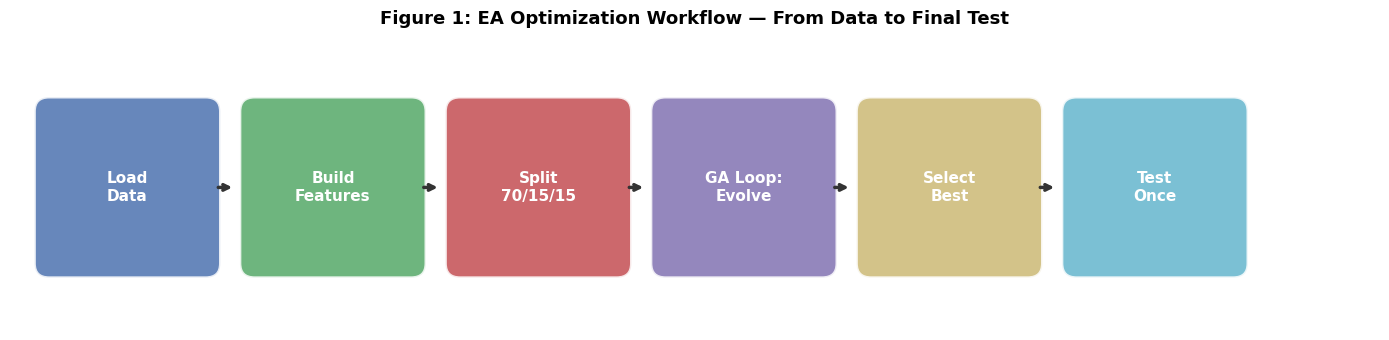

Saved: /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase2/plots/fig1_ea_workflow.png
Caption: This shows the six main steps. The GA loop (purple) is where evolution happens. The test step (blue) happens only once at the end.


In [69]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 3)
ax.axis('off')
fig.patch.set_facecolor('white')

steps = [
    ("Load\nData", "#4C72B0"),
    ("Build\nFeatures", "#55A868"),
    ("Split\n70/15/15", "#C44E52"),
    ("GA Loop:\nEvolve", "#8172B2"),
    ("Select\nBest", "#CCB974"),
    ("Test\nOnce", "#64B5CD"),
]

for i, (label, color) in enumerate(steps):
    x = 1.2 + i * 2.1
    rect = mpatches.FancyBboxPatch((x - 0.8, 0.7), 1.6, 1.6,
                                    boxstyle="round,pad=0.15",
                                    facecolor=color, edgecolor='white', linewidth=2, alpha=0.85)
    ax.add_patch(rect)
    ax.text(x, 1.5, label, ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    if i < len(steps) - 1:
        ax.annotate('', xy=(x + 1.1, 1.5), xytext=(x + 0.9, 1.5),
                     arrowprops=dict(arrowstyle='->', color='#333333', lw=2.5))

ax.set_title("Figure 1: EA Optimization Workflow — From Data to Final Test",
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
fig1_path = ARTIFACTS_DIR / "plots" / "fig1_ea_workflow.png"
plt.savefig(fig1_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved: {fig1_path.resolve()}")
print("Caption: This shows the six main steps. The GA loop (purple) is where evolution happens. The test step (blue) happens only once at the end.")


## Figure 2: Search Space — What One Candidate Contains

Each candidate (also called an "individual" or "chromosome") is a set of five hyperparameter choices. The GA evolves these settings over many generations.


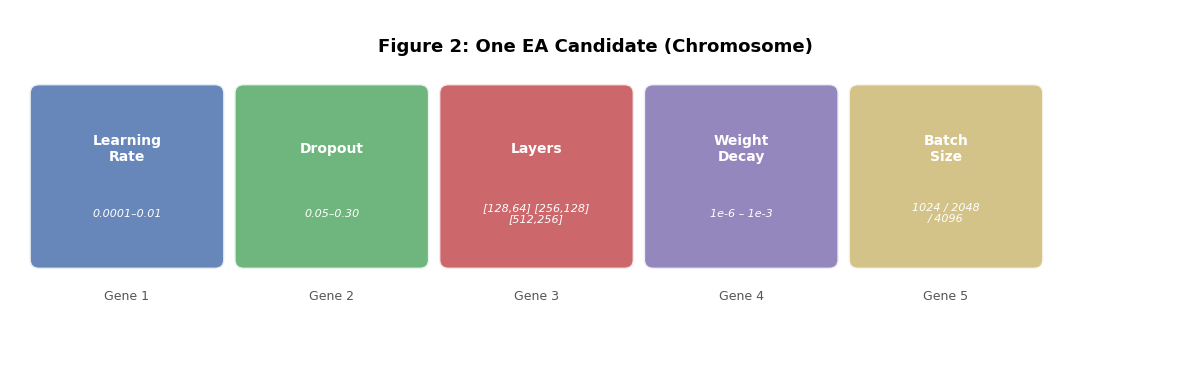

Saved: /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase2/plots/fig2_chromosome.png
Caption: Each candidate is defined by 5 genes. The GA changes these values through crossover and mutation to find the best combination.


In [70]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 4))
ax.set_xlim(0, 12)
ax.set_ylim(0, 4)
ax.axis('off')
fig.patch.set_facecolor('white')

genes = [
    ("Learning\nRate", "0.0001–0.01", "#4C72B0"),
    ("Dropout", "0.05–0.30", "#55A868"),
    ("Layers", "[128,64] [256,128]\n[512,256]", "#C44E52"),
    ("Weight\nDecay", "1e-6 – 1e-3", "#8172B2"),
    ("Batch\nSize", "1024 / 2048\n/ 4096", "#CCB974"),
]

ax.text(6, 3.6, "Figure 2: One EA Candidate (Chromosome)", ha='center', va='center',
        fontsize=13, fontweight='bold')

for i, (name, rng, color) in enumerate(genes):
    x = 1.2 + i * 2.1
    rect = mpatches.FancyBboxPatch((x - 0.9, 1.3), 1.8, 1.8,
                                    boxstyle="round,pad=0.1",
                                    facecolor=color, edgecolor='white', linewidth=2, alpha=0.85)
    ax.add_patch(rect)
    ax.text(x, 2.5, name, ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    ax.text(x, 1.8, rng, ha='center', va='center', fontsize=8, color='white', style='italic')

    # Gene label
    ax.text(x, 0.9, f"Gene {i+1}", ha='center', va='center', fontsize=9, color='#555555')

plt.tight_layout()
fig2_path = ARTIFACTS_DIR / "plots" / "fig2_chromosome.png"
plt.savefig(fig2_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved: {fig2_path.resolve()}")
print("Caption: Each candidate is defined by 5 genes. The GA changes these values through crossover and mutation to find the best combination.")


## Main EA Optimization Cell

> **What this does:** This is the core of the notebook. It defines the neural network, the fitness function, the GA operators (selection, crossover, mutation), and runs the full evolutionary search.  
> **Why it matters:** This is where all the optimization happens. Every candidate is trained, scored on validation data, and the best settings "survive" into the next generation.  
> **What it saves:** generation logs (CSV), convergence plots (PNG), best model checkpoint (.pt), final metrics (CSV), environment snapshot (JSON).

### How the GA works step by step:
1. **Create** a random population of 20 candidates
2. **Train** each candidate's neural network for a few epochs
3. **Score** each candidate using validation R² (fitness)
4. **Select** the best candidates as "parents"
5. **Crossover** two parents to make a child (mix their settings)
6. **Mutate** some settings randomly (small random tweaks)
7. **Keep** the top 2 unchanged (elitism)
8. **Repeat** for 15 generations
9. **Pick** the overall best candidate and evaluate it on the test set exactly once

### Key numbers explained:
- `EPOCHS_PER_CANDIDATE = 3` → Each candidate trains for only 3 passes through the data, to keep things fast.
- `PATIENCE = 3` → Stop early inside one candidate if validation does not improve for 3 rounds.
- `EVAL_BATCH_SIZE = 65536` → Process 65,536 samples at once during prediction (GPU-efficient).
- `CLIP_MIN_LOG = -2.0`, `CLIP_MAX_LOG = 13.0` → Prevent extreme predictions that would break the math.
- `TRAIN_IN_LOG_SPACE = True` → We train on log-transformed trip durations for numerical stability, then convert back to seconds for scoring.


Device: cuda
Artifacts: /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase2
Saved environment snapshot to: /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase2/environment_snapshot_phase2.json
NRP image hint: gitlab-registry.nrp-nautilus.io/prp/jupyter-stack/prp-pytorch2:v1.0

EA compute budget:
  Population size : 20
  Generations     : 15
  Theoretical eval: 300
  Mutation rate   : 0.1
  Crossover rate  : 0.8
  Elite count     : 2

Smoke test candidate:
{'learning_rate': 0.0035311169138214113, 'dropout': 0.1597196099380131, 'layers': (256, 128), 'weight_decay': 0.00012362436879527074, 'batch_size': 4096}
Validation R²   : -0.012621
Validation MAPE : 57.6381%
Generation 01 | best_val_R2=0.008488 | mean_val_R2=-1.774567 | best_val_MAPE=34.5805% | mean_val_MAPE=91.1926%
Generation 02 | best_val_R2=0.008488 | mean_val_R2=-0.040156 | best_val_MAPE=33.0547% | mean_val_MAPE=39.0588%
Generation 03 | best_val_R2=0.008488 | mean_val_R2=-0.002917 | best_val_MAPE=33.0547% | mean_val

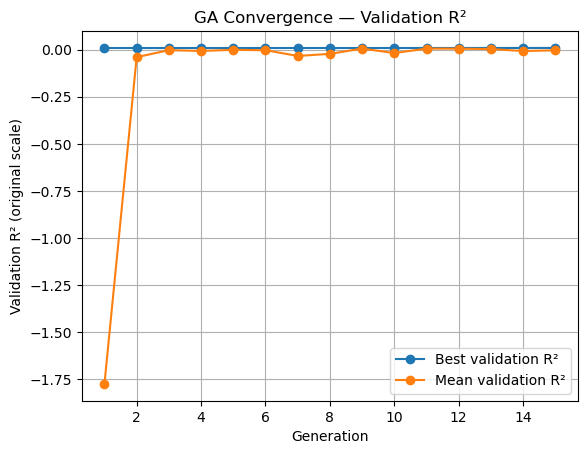

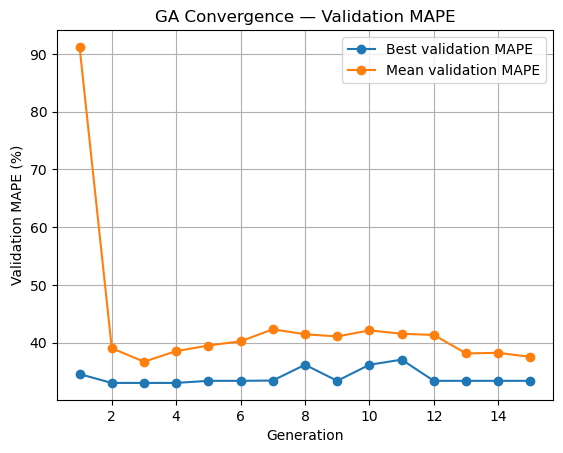

Saved plots:
  /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase2/plots/ga_convergence_r2.png
  /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase2/plots/ga_convergence_mape.png

=== Final Best Individual ===
{'learning_rate': 0.00453874603866011, 'dropout': 0.2511910893742005, 'layers': (256, 128), 'weight_decay': 0.00024083130528865945, 'batch_size': 1024}

=== Validation Metrics (Best EA Candidate) ===
r2: 0.006821
rmse: 5921.140254
mae: 373.454264
mape: 36.1624%
r2_log: 0.623811
rmse_log: 0.485765
mae_log: 0.334752

=== Test Metrics (Final One-Time Evaluation) ===
r2: -0.240014
rmse: 3390.400267
mae: 354.950491
mape: 36.1972%
r2_log: 0.627582
rmse_log: 0.483605
mae_log: 0.334401

Saved final artifacts:
  /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase2/ea_final_metrics.csv
  /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase2/best_ea_individual.json
  /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase2/best_ea_model.pt

=== Compute Summary ===

In [71]:
# ============================================================
# Phase 2 — EA Optimization (GPU-accelerated, compliant version)
# Primary EA fitness: validation R² on ORIGINAL scale
# Secondary tracked metric: validation MAPE on ORIGINAL scale
# Training target: log1p(duration) for stability (fitness/reporting
#                  are still on original scale)
# ============================================================

import os
import sys
import time
import json
import copy
import random
import platform
import subprocess
from pathlib import Path
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ------------------------------------------------------------
# 0) Sanity checks: required objects from earlier cells
# ------------------------------------------------------------
required_names = [
    "SEED", "ARTIFACTS_DIR", "device",
    "X_train_s", "X_val_s", "X_test_s",
    "y_train_orig", "y_val_orig", "y_test_orig",
    "y_train_log", "y_val_log", "y_test_log",
    "log_generation_stats"
]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise NameError(f"Missing required variables from earlier cells: {missing}")

ARTIFACTS_DIR = Path(ARTIFACTS_DIR)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR = ARTIFACTS_DIR / "plots"
LOG_DIR = ARTIFACTS_DIR / "ea_trial_logs"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

print("Device:", device)
print("Artifacts:", ARTIFACTS_DIR.resolve())

# ------------------------------------------------------------
# 1) NRP / environment snapshot (auditable evidence)
# ------------------------------------------------------------
def _safe_cmd(cmd):
    try:
        return subprocess.check_output(cmd, text=True, stderr=subprocess.STDOUT)
    except Exception as e:
        return f"(command failed: {cmd} -> {e})\n"

image_hint = (
    os.environ.get("JUPYTER_IMAGE_SPEC")
    or os.environ.get("CONTAINER_IMAGE")
    or os.environ.get("JUPYTERHUB_IMAGE")
    or os.environ.get("IMAGE_NAME")
    or "UNKNOWN"
)

gpu_count = torch.cuda.device_count() if torch.cuda.is_available() else 0
env_snapshot = {
    "timestamp": pd.Timestamp.now().isoformat(),
    "platform": platform.platform(),
    "python_version": sys.version.replace("\n", " "),
    "python_executable": sys.executable,
    "torch_version": torch.__version__,
    "cuda_available": bool(torch.cuda.is_available()),
    "cuda_version": torch.version.cuda,
    "device": str(device),
    "gpu_count": int(gpu_count),
    "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
    "nrp_image_hint": image_hint,
}

env_path = ARTIFACTS_DIR / "environment_snapshot_phase2.json"
env_path.write_text(json.dumps(env_snapshot, indent=2), encoding="utf-8")

print("Saved environment snapshot to:", env_path.resolve())
print("NRP image hint:", image_hint)

# ------------------------------------------------------------
# 2) GPU acceleration controls
# ------------------------------------------------------------
USE_CUDA = (torch.cuda.is_available() and str(device).startswith("cuda"))
NUM_GPUS = torch.cuda.device_count() if USE_CUDA else 0
USE_DATA_PARALLEL = NUM_GPUS > 1
USE_AMP = USE_CUDA
PIN_MEMORY = USE_CUDA

# Important notebook fix:
# custom Dataset + Jupyter + multiprocessing workers can crash with:
# "Can't get attribute 'TabularDataset' on <module '__main__'>"
NUM_WORKERS = 0
PERSISTENT_WORKERS = False
PREFETCH_FACTOR = None

EVAL_BATCH_SIZE = 65536 if USE_CUDA else 16384

# ------------------------------------------------------------
# 3) Reproducibility helpers
# ------------------------------------------------------------
def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    try:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except Exception:
        pass

seed_everything(SEED)

# ------------------------------------------------------------
# 4) Metrics + target handling
# ------------------------------------------------------------
TRAIN_IN_LOG_SPACE = True
CLIP_MIN_LOG = -2.0
CLIP_MAX_LOG = 13.0

def safe_expm1(yhat_log, clip_min=CLIP_MIN_LOG, clip_max=CLIP_MAX_LOG):
    yhat_log = np.asarray(yhat_log).reshape(-1)
    yhat_log = np.clip(yhat_log, clip_min, clip_max)
    return np.expm1(yhat_log)

def mape(y_true, y_pred, eps=1.0):
    y_true = np.asarray(y_true).reshape(-1).astype(np.float64)
    y_pred = np.asarray(y_pred).reshape(-1).astype(np.float64)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)

def regression_metrics_original(y_true_orig, y_pred_orig):
    return {
        "r2": float(r2_score(y_true_orig, y_pred_orig)),
        "rmse": float(mean_squared_error(y_true_orig, y_pred_orig, squared=False)),
        "mae": float(mean_absolute_error(y_true_orig, y_pred_orig)),
        "mape": float(mape(y_true_orig, y_pred_orig)),
    }

def regression_metrics_log(y_true_log, y_pred_log):
    return {
        "r2_log": float(r2_score(y_true_log, y_pred_log)),
        "rmse_log": float(mean_squared_error(y_true_log, y_pred_log, squared=False)),
        "mae_log": float(mean_absolute_error(y_true_log, y_pred_log)),
    }

def autocast_context():
    if USE_AMP:
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return nullcontext()

# ------------------------------------------------------------
# 5) Data interface
# ------------------------------------------------------------
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.as_tensor(np.asarray(X), dtype=torch.float32)
        self.y = torch.as_tensor(np.asarray(y), dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, i):
        return self.X[i], self.y[i]

X_train_np = np.asarray(X_train_s, dtype=np.float32)
X_val_np   = np.asarray(X_val_s, dtype=np.float32)
X_test_np  = np.asarray(X_test_s, dtype=np.float32)

# Training target can be log-space, but fitness/reporting remain original-scale.
y_train_fit = y_train_log if TRAIN_IN_LOG_SPACE else y_train_orig
y_val_fit   = y_val_log if TRAIN_IN_LOG_SPACE else y_val_orig
y_test_fit  = y_test_log if TRAIN_IN_LOG_SPACE else y_test_orig

# Build shared datasets/tensors once to reduce repeated setup cost.
train_ds = TabularDataset(X_train_np, y_train_fit)
X_val_tensor = torch.as_tensor(X_val_np, dtype=torch.float32, device=device)
X_test_tensor = torch.as_tensor(X_test_np, dtype=torch.float32, device=device)

def make_train_loader(batch_size, seed):
    generator = torch.Generator()
    generator.manual_seed(seed)
    kwargs = dict(
        dataset=train_ds,
        batch_size=int(batch_size),
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=PERSISTENT_WORKERS,
        generator=generator,
    )
    if PREFETCH_FACTOR is not None:
        kwargs["prefetch_factor"] = PREFETCH_FACTOR
    return DataLoader(**kwargs)

# ------------------------------------------------------------
# 6) Model / individual encoding
# ------------------------------------------------------------
SEARCH_SPACE = {
    "learning_rate": (1e-4, 1e-2),                   # continuous (log-uniform)
    "dropout": (0.05, 0.30),                         # continuous
    "layers": [(128, 64), (256, 128), (512, 256)],  # discrete
    "weight_decay": (1e-6, 1e-3),                   # continuous (log-uniform)
    "batch_size": [1024, 2048, 4096] if USE_CUDA else [1024, 2048],
}

POPULATION_SIZE = 20
GENERATIONS = 15
MUTATION_RATE = 0.10
CROSSOVER_RATE = 0.80
ELITE_COUNT = 2

# Fixed internal training budget per candidate
EPOCHS_PER_CANDIDATE = 3
PATIENCE = 3

print("\nEA compute budget:")
print("  Population size :", POPULATION_SIZE)
print("  Generations     :", GENERATIONS)
print("  Theoretical eval:", POPULATION_SIZE * GENERATIONS)
print("  Mutation rate   :", MUTATION_RATE)
print("  Crossover rate  :", CROSSOVER_RATE)
print("  Elite count     :", ELITE_COUNT)

def sample_log_uniform(low, high, rng):
    return float(np.exp(rng.uniform(np.log(low), np.log(high))))

def create_individual(rng=None):
    rng = np.random.default_rng(SEED) if rng is None else rng
    return {
        "learning_rate": sample_log_uniform(*SEARCH_SPACE["learning_rate"], rng=rng),
        "dropout": float(rng.uniform(*SEARCH_SPACE["dropout"])),
        "layers": tuple(SEARCH_SPACE["layers"][int(rng.integers(0, len(SEARCH_SPACE["layers"])))]),
        "weight_decay": sample_log_uniform(*SEARCH_SPACE["weight_decay"], rng=rng),
        "batch_size": int(SEARCH_SPACE["batch_size"][int(rng.integers(0, len(SEARCH_SPACE["batch_size"])))]),
    }

def individual_key(ind):
    return (
        round(float(ind["learning_rate"]), 10),
        round(float(ind["dropout"]), 10),
        tuple(ind["layers"]),
        round(float(ind["weight_decay"]), 10),
        int(ind["batch_size"]),
    )

def unwrap_model(model):
    return model.module if hasattr(model, "module") else model

def build_model_from_individual(individual, in_dim):
    layers = individual["layers"]
    dropout = float(individual["dropout"])
    net = []
    prev = in_dim
    for h in layers:
        net.append(nn.Linear(prev, h))
        net.append(nn.ReLU())
        net.append(nn.Dropout(dropout))
        prev = h
    net.append(nn.Linear(prev, 1))
    base_model = nn.Sequential(*net).to(device)

    if USE_DATA_PARALLEL:
        base_model = nn.DataParallel(base_model)
    return base_model

# ------------------------------------------------------------
# 7) Prediction helpers (batched on-device inference)
# ------------------------------------------------------------
def model_predict_fit_space(model, X_tensor):
    model.eval()
    preds = []
    with torch.inference_mode():
        with autocast_context():
            for start in range(0, X_tensor.shape[0], EVAL_BATCH_SIZE):
                xb = X_tensor[start:start + EVAL_BATCH_SIZE]
                out = model(xb).view(-1)
                preds.append(out.detach().float().cpu())
    preds = torch.cat(preds).numpy().reshape(-1)
    if TRAIN_IN_LOG_SPACE:
        preds = np.clip(preds, CLIP_MIN_LOG, CLIP_MAX_LOG)
    return preds

def fit_to_original_scale(pred_fit):
    if TRAIN_IN_LOG_SPACE:
        return safe_expm1(pred_fit)
    return np.maximum(pred_fit, 0.0)

def model_predict_original(model, X_tensor):
    pred_fit = model_predict_fit_space(model, X_tensor)
    return fit_to_original_scale(pred_fit)
# ------------------------------------------------------------
# 8) Train/evaluate one candidate
# ------------------------------------------------------------
def evaluate_candidate(individual, trial_seed):
    """
    Train on TRAIN only.
    Select epoch by VALIDATION R² on ORIGINAL scale.
    Return both primary metric (val_r2) and secondary metric (val_mape).
    """
    seed_everything(trial_seed)

    model = build_model_from_individual(individual, in_dim=X_train_np.shape[1])
    train_loader = make_train_loader(batch_size=individual["batch_size"], seed=trial_seed)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=float(individual["learning_rate"]),
        weight_decay=float(individual["weight_decay"]),
    )
    loss_fn = nn.SmoothL1Loss(beta=0.5) if TRAIN_IN_LOG_SPACE else nn.MSELoss()
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    best_state = None
    best_epoch = 0
    best_val_r2 = -np.inf
    best_epoch_metrics = None
    patience_counter = 0
    history = []

    for epoch in range(1, EPOCHS_PER_CANDIDATE + 1):
        model.train()
        running_loss = 0.0
        seen = 0

        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=PIN_MEMORY)
            yb = yb.to(device, non_blocking=PIN_MEMORY).view(-1)

            optimizer.zero_grad(set_to_none=True)
            with autocast_context():
                preds = model(xb).view(-1)
                if TRAIN_IN_LOG_SPACE:
                    preds = torch.clamp(preds, CLIP_MIN_LOG, CLIP_MAX_LOG)
                loss = loss_fn(preds, yb)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            running_loss += float(loss.detach().item()) * xb.size(0)
            seen += xb.size(0)

        train_loss = running_loss / max(seen, 1)

        # Single validation pass, then score in both spaces
        val_pred_fit = model_predict_fit_space(model, X_val_tensor)
        val_pred_orig = fit_to_original_scale(val_pred_fit)

        val_metrics_orig = regression_metrics_original(y_val_orig, val_pred_orig)
        val_metrics_log = regression_metrics_log(y_val_fit, val_pred_fit)

        row = {
            "epoch": epoch,
            "train_loss": float(train_loss),
            **{f"val_{k}": v for k, v in val_metrics_orig.items()},
            **{f"val_{k}": v for k, v in val_metrics_log.items()},
        }
        history.append(row)

        # Early stopping within candidate training: based on PRIMARY metric (val_r2)
        if val_metrics_orig["r2"] > best_val_r2 + 1e-6:
            best_val_r2 = val_metrics_orig["r2"]
            best_epoch = epoch
            best_epoch_metrics = {
                **val_metrics_orig,
                **val_metrics_log,
            }
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in unwrap_model(model).state_dict().items()
            }
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                break

    if best_state is None:
        raise RuntimeError("No valid state captured during candidate evaluation.")
    unwrap_model(model).load_state_dict(best_state)

    hist_path = LOG_DIR / f"candidate_{abs(hash(individual_key(individual))) % 10**10}_{trial_seed}.csv"
    pd.DataFrame(history).to_csv(hist_path, index=False)

    result = {
        "model": model,
        "best_epoch": int(best_epoch),
        "history_csv": str(hist_path),
        "val_r2": float(best_epoch_metrics["r2"]),
        "val_rmse": float(best_epoch_metrics["rmse"]),
        "val_mae": float(best_epoch_metrics["mae"]),
        "val_mape": float(best_epoch_metrics["mape"]),
        "val_r2_log": float(best_epoch_metrics["r2_log"]),
        "val_rmse_log": float(best_epoch_metrics["rmse_log"]),
        "val_mae_log": float(best_epoch_metrics["mae_log"]),
    }
    return result

# ------------------------------------------------------------
# 9) GA operators
# ------------------------------------------------------------
def initialize_population(size, seed=SEED):
    rng = np.random.default_rng(seed)
    return [create_individual(rng) for _ in range(size)]

def tournament_selection(population, metrics_list, k=3, seed=None):
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(population), size=k, replace=False)
    best_idx = max(idxs, key=lambda i: metrics_list[i]["val_r2"])  # maximize validation R²
    return copy.deepcopy(population[best_idx])

def crossover(parent1, parent2, seed=None):
    rng = np.random.default_rng(seed)
    child = {}
    for key in parent1.keys():
        child[key] = copy.deepcopy(parent1[key] if rng.random() < 0.5 else parent2[key])
    return child

def mutate(individual, mutation_rate=MUTATION_RATE, seed=None):
    rng = np.random.default_rng(seed)
    child = copy.deepcopy(individual)

    if rng.random() < mutation_rate:
        child["learning_rate"] = sample_log_uniform(*SEARCH_SPACE["learning_rate"], rng=rng)

    if rng.random() < mutation_rate:
        child["dropout"] = float(rng.uniform(*SEARCH_SPACE["dropout"]))

    if rng.random() < mutation_rate:
        child["layers"] = tuple(SEARCH_SPACE["layers"][int(rng.integers(0, len(SEARCH_SPACE["layers"])))])

    if rng.random() < mutation_rate:
        child["weight_decay"] = sample_log_uniform(*SEARCH_SPACE["weight_decay"], rng=rng)

    if rng.random() < mutation_rate:
        child["batch_size"] = int(SEARCH_SPACE["batch_size"][int(rng.integers(0, len(SEARCH_SPACE["batch_size"])))])

    return child

# ------------------------------------------------------------
# 10) Fitness cache + fitness function
# ------------------------------------------------------------
fitness_cache = {}
fitness_calls = 0

def fitness(individual, eval_id):
    """
    Authoritative EA fitness.
    Returns PRIMARY metric only: validation R² on ORIGINAL scale.
    Secondary metric (validation MAPE) is also computed and cached.
    """
    global fitness_calls

    key = individual_key(individual)
    if key not in fitness_cache:
        fitness_calls += 1
        result = evaluate_candidate(individual, trial_seed=SEED + eval_id)
        fitness_cache[key] = {
            "val_r2": result["val_r2"],
            "val_mape": result["val_mape"],
            "best_epoch": result["best_epoch"],
        }

    return fitness_cache[key]["val_r2"]

# ------------------------------------------------------------
# 11) Smoke test
# ------------------------------------------------------------
def get_cached_metrics(individual):
    key = individual_key(individual)
    if key not in fitness_cache:
        raise ValueError("Individual not found in fitness_cache")
    return fitness_cache[key]



_smoke_individual = create_individual(np.random.default_rng(SEED))
_ = fitness(_smoke_individual, eval_id=1)
_smoke_metrics = get_cached_metrics(_smoke_individual)

print("\nSmoke test candidate:")
print(_smoke_individual)
print(f"Validation R²   : {_smoke_metrics['val_r2']:.6f}")
print(f"Validation MAPE : {_smoke_metrics['val_mape']:.4f}%")

# ------------------------------------------------------------
# 12) Main GA loop
# ------------------------------------------------------------
seed_everything(SEED)
generation_logs = []   # reset in case cell is rerun
ga_start = time.time()

population = initialize_population(POPULATION_SIZE, seed=SEED)
best_individual = None
best_metrics = None
all_generation_summaries = []
eval_counter = 1  # deterministic per-fitness call seeding offset

for g in range(1, GENERATIONS + 1):
    population_metrics = []
    for ind in population:
        _ = fitness(ind, eval_id=eval_counter)
        metrics = get_cached_metrics(ind)
        population_metrics.append(metrics)
        eval_counter += 1

    gen_row = log_generation_stats(generation=g, population_metrics=population_metrics)
    all_generation_summaries.append(gen_row)

    best_idx = int(np.argmax([m["val_r2"] for m in population_metrics]))
    current_best_ind = population[best_idx]
    current_best_metrics = population_metrics[best_idx]

    if (best_metrics is None) or (current_best_metrics["val_r2"] > best_metrics["val_r2"]):
        best_individual = copy.deepcopy(current_best_ind)
        best_metrics = dict(current_best_metrics)

    print(
        f"Generation {g:02d} | "
        f"best_val_R2={gen_row['best_val_r2']:.6f} | "
        f"mean_val_R2={gen_row['mean_val_r2']:.6f} | "
        f"best_val_MAPE={gen_row['best_val_mape']:.4f}% | "
        f"mean_val_MAPE={gen_row['mean_val_mape']:.4f}%"
    )

    ranked = np.argsort([-m["val_r2"] for m in population_metrics])  # descending by val_r2
    next_population = [copy.deepcopy(population[i]) for i in ranked[:ELITE_COUNT]]

    while len(next_population) < POPULATION_SIZE:
        p1 = tournament_selection(population, population_metrics, k=3, seed=SEED + g * 100 + len(next_population))
        p2 = tournament_selection(population, population_metrics, k=3, seed=SEED + g * 1000 + len(next_population))

        if np.random.rand() < CROSSOVER_RATE:
            child = crossover(p1, p2, seed=SEED + g * 10 + len(next_population))
        else:
            child = copy.deepcopy(p1)

        child = mutate(child, mutation_rate=MUTATION_RATE, seed=SEED + g * 10000 + len(next_population))
        next_population.append(child)

    population = next_population[:POPULATION_SIZE]

ga_end = time.time()
total_runtime_sec = ga_end - ga_start

# ------------------------------------------------------------
# 13) Save generation logs
# ------------------------------------------------------------
generation_logs_df = pd.DataFrame(generation_logs)
gen_logs_path = ARTIFACTS_DIR / "generation_logs.csv"
generation_logs_df.to_csv(gen_logs_path, index=False)
print("\nSaved generation logs to:", gen_logs_path.resolve())

# ------------------------------------------------------------
# 14) Convergence plots (R² + MAPE)
# ------------------------------------------------------------
plt.figure()
plt.plot(generation_logs_df["generation"], generation_logs_df["best_val_r2"], marker="o", label="Best validation R²")
plt.plot(generation_logs_df["generation"], generation_logs_df["mean_val_r2"], marker="o", label="Mean validation R²")
plt.xlabel("Generation")
plt.ylabel("Validation R² (original scale)")
plt.title("GA Convergence — Validation R²")
plt.grid(True)
plt.legend()
r2_plot_path = PLOTS_DIR / "ga_convergence_r2.png"
plt.savefig(r2_plot_path, bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(generation_logs_df["generation"], generation_logs_df["best_val_mape"], marker="o", label="Best validation MAPE")
plt.plot(generation_logs_df["generation"], generation_logs_df["mean_val_mape"], marker="o", label="Mean validation MAPE")
plt.xlabel("Generation")
plt.ylabel("Validation MAPE (%)")
plt.title("GA Convergence — Validation MAPE")
plt.grid(True)
plt.legend()
mape_plot_path = PLOTS_DIR / "ga_convergence_mape.png"
plt.savefig(mape_plot_path, bbox_inches="tight")
plt.show()

print("Saved plots:")
print(" ", r2_plot_path.resolve())
print(" ", mape_plot_path.resolve())

# ------------------------------------------------------------
# 15) Final selected model (validation-only selection already done)
# ------------------------------------------------------------
final_result = evaluate_candidate(best_individual, trial_seed=SEED + 999999)
best_model = final_result["model"]

val_pred_fit = model_predict_fit_space(best_model, X_val_tensor)
val_pred_orig = fit_to_original_scale(val_pred_fit)
final_val_metrics = {
    **regression_metrics_original(y_val_orig, val_pred_orig),
    **regression_metrics_log(y_val_fit, val_pred_fit),
}

test_pred_fit = model_predict_fit_space(best_model, X_test_tensor)
test_pred_orig = fit_to_original_scale(test_pred_fit)
final_test_metrics = {
    **regression_metrics_original(y_test_orig, test_pred_orig),
    **regression_metrics_log(y_test_fit, test_pred_fit),
}

print("\n=== Final Best Individual ===")
print(best_individual)

print("\n=== Validation Metrics (Best EA Candidate) ===")
for k, v in final_val_metrics.items():
    if "mape" in k:
        print(f"{k}: {v:.4f}%")
    else:
        print(f"{k}: {v:.6f}")

print("\n=== Test Metrics (Final One-Time Evaluation) ===")
for k, v in final_test_metrics.items():
    if "mape" in k:
        print(f"{k}: {v:.4f}%")
    else:
        print(f"{k}: {v:.6f}")

# ------------------------------------------------------------
# 16) Save final artifacts
# ------------------------------------------------------------
final_summary = pd.DataFrame([
    {"split": "validation", **final_val_metrics},
    {"split": "test", **final_test_metrics},
])
final_summary_path = ARTIFACTS_DIR / "ea_final_metrics.csv"
final_summary.to_csv(final_summary_path, index=False)

best_individual_path = ARTIFACTS_DIR / "best_ea_individual.json"
with open(best_individual_path, "w", encoding="utf-8") as f:
    json.dump(best_individual, f, indent=2)

best_model_ckpt = {
    "model_state_dict": {
        k: v.detach().cpu()
        for k, v in unwrap_model(best_model).state_dict().items()
    },
    "best_individual": best_individual,
    "train_in_log_space": TRAIN_IN_LOG_SPACE,
    "clip_min_log": CLIP_MIN_LOG,
    "clip_max_log": CLIP_MAX_LOG,
    "seed": SEED,
    "use_data_parallel": USE_DATA_PARALLEL,
}
best_model_path = ARTIFACTS_DIR / "best_ea_model.pt"
torch.save(best_model_ckpt, best_model_path)

print("\nSaved final artifacts:")
print(" ", final_summary_path.resolve())
print(" ", best_individual_path.resolve())
print(" ", best_model_path.resolve())

# ------------------------------------------------------------
# 17) Compute-budget summary
# ------------------------------------------------------------
theoretical_evals = POPULATION_SIZE * GENERATIONS
actual_unique_evals = fitness_calls

print("\n=== Compute Summary ===")
print("Population size           :", POPULATION_SIZE)
print("Generations               :", GENERATIONS)
print("Theoretical evaluations   :", theoretical_evals)
print("Actual unique evaluations :", actual_unique_evals)
print("Total runtime (seconds)   :", round(total_runtime_sec, 2))
print("Total runtime (minutes)   :", round(total_runtime_sec / 60.0, 2))
print("Device used               :", device)
print("GPU count                 :", NUM_GPUS)
print("Environment snapshot      :", env_path.name)

# ------------------------------------------------------------
# 18) Completion message
# ------------------------------------------------------------
print("\nPhase 2 Step 2 COMPLETE — EA optimization executed successfully.")
print("Primary optimization metric: validation R² (original scale)")
print("Secondary tracked metric: validation MAPE (original scale)")
print("GPU-aware acceleration enabled: AMP, batched on-device inference, pinned-memory loaders.")
if USE_DATA_PARALLEL:
    print("Multi-GPU DataParallel active.")


### Figure 3: GA Convergence — Validation R²

The plot above (saved as `ga_convergence_r2.png`) shows how the best and average validation R² changed across generations.

**How to read it:**
- The **blue line** (best) should go up over time — this means the EA is finding better candidates.
- The **orange line** (mean) shows the average quality of all 20 candidates.
- If both lines flatten out, the EA has converged (stopped improving).
- **Higher is better** for R².

### Figure 4: GA Convergence — Validation MAPE

The second plot (saved as `ga_convergence_mape.png`) shows the same idea for MAPE.

**How to read it:**
- The **blue line** (best) should go down over time — lower error is better.
- The **orange line** (mean) shows average error across the population.
- **Lower is better** for MAPE.


---
## Phase 2 — Step 3.1: Load Phase 1 Neural Network Reference

> **What this does:** Loads the predictions from the Phase 1 neural network so we can compare it against the EA-optimized model.  
> **Why it matters:** The whole point of Phase 2 is to test whether the EA can improve upon Phase 1. We need both sets of predictions on the same test data.

**What we load:** A CSV file containing the true trip durations and the Phase 1 NN's predictions, both on the original scale (seconds).

**Important rule (no leakage):** These values come from the final holdout test set, which was never used during training or tuning.


In [72]:
# ============================================================
# Load Phase 1 NN predictions from the shared artifacts folder
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

PHASE1_PRED_PATH = Path("../artifacts/phase1_nn_test_predictions.csv")
assert PHASE1_PRED_PATH.exists(), f"Missing file: {PHASE1_PRED_PATH.resolve()}"

phase1_df = pd.read_csv(PHASE1_PRED_PATH)

phase1_y_test_orig = phase1_df["y_true"].to_numpy().astype(np.float64)
nn_test_pred_orig = phase1_df["nn_pred"].to_numpy().astype(np.float64)

print("Loaded Phase 1 predictions from:", PHASE1_PRED_PATH.resolve())
print("Rows:", len(phase1_df))
display(phase1_df.head())

Loaded Phase 1 predictions from: /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase1_nn_test_predictions.csv
Rows: 150000


,y_true,nn_pred
0,893.0,784.51980
1,387.0,235.01308
2,2491.0,1567.52590
3,947.0,998.66254
4,704.0,752.82860


### Compute Phase 1 NN Metrics

> **What this does:** Calculates R², RMSE, MAE, and MAPE for the Phase 1 NN predictions.


In [73]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def mape(y_true, y_pred, eps=1.0):
    y_true = np.asarray(y_true).reshape(-1).astype(np.float64)
    y_pred = np.asarray(y_pred).reshape(-1).astype(np.float64)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)

phase1_nn_metrics = {
    "r2": float(r2_score(phase1_y_test_orig, nn_test_pred_orig)),
    "rmse": float(mean_squared_error(phase1_y_test_orig, nn_test_pred_orig, squared=False)),
    "mae": float(mean_absolute_error(phase1_y_test_orig, nn_test_pred_orig)),
    "mape": float(mape(phase1_y_test_orig, nn_test_pred_orig)),
}

print("Phase 1 NN metrics:")
print(phase1_nn_metrics)

Phase 1 NN metrics:
{'r2': -0.1606901954679134, 'rmse': 3280.165841465935, 'mae': 320.0547231257, 'mape': 32.51302294434897}


## Sanity Check — Same Test Set Verification

> **What this does:** Confirms that the Phase 1 NN and the EA model were evaluated on the **exact same test trips**, in the same order.  
> **Why it matters:** Our statistical comparison is "paired" — each EA prediction is compared to the NN prediction for the **same trip**. If the test sets don't match, the comparison is meaningless.


In [74]:
ea_y_test_orig = np.asarray(y_test_orig).reshape(-1).astype(np.float64)
ea_test_pred_orig = np.asarray(test_pred_orig).reshape(-1).astype(np.float64)

assert len(phase1_y_test_orig) == len(ea_y_test_orig), "Phase 1 and EA test lengths do not match."
assert len(nn_test_pred_orig) == len(ea_test_pred_orig), "Prediction lengths do not match."

same_targets = np.allclose(phase1_y_test_orig, ea_y_test_orig)
print("Do Phase 1 and EA use the same test targets?", same_targets)

if not same_targets:
    raise ValueError("Test targets do not match. Paired comparison is invalid until the same Phase 1 split is reused.")

Do Phase 1 and EA use the same test targets? True


## Phase 2 — Step 3.1: Final Model Comparison

> **What this does:** Creates a side-by-side comparison table of the Phase 1 NN vs. the EA-optimized NN.  
> **Why it matters:** This is the main result of the project — did the EA actually improve the model?

### Metrics reported:
- **R²** → how well the model explains variation (higher is better)
- **MAPE** → average percentage error (lower is better)
- **RMSE** → root mean squared error in seconds (lower is better)
- **MAE** → mean absolute error in seconds (lower is better)

### Deltas:
- **ΔR² = EA − Phase 1 NN** → positive means EA is better
- **ΔMAPE = EA − Phase 1 NN** → negative means EA has less error


In [75]:
# ============================================================
# Final comparison table: Phase 1 NN vs EA-Optimized NN
# ============================================================

ea_metrics = {
    "r2": float(final_test_metrics["r2"]),
    "rmse": float(final_test_metrics["rmse"]),
    "mae": float(final_test_metrics["mae"]),
    "mape": float(final_test_metrics["mape"]),
}

phase1_nn_runtime_sec = None   # fill in if you tracked it in Phase 1
phase1_nn_evaluations = 20     # replace if you have the exact count
ea_runtime_sec = float(total_runtime_sec)
ea_evaluations = float(TOTAL_EVALUATIONS)

comparison_df = pd.DataFrame([
    {
        "Model": "Phase 1 NN",
        "R2": phase1_nn_metrics["r2"],
        "MAPE": phase1_nn_metrics["mape"],
        "RMSE": phase1_nn_metrics["rmse"],
        "MAE": phase1_nn_metrics["mae"],
        "Runtime_sec": phase1_nn_runtime_sec,
        "Evaluations": phase1_nn_evaluations,
    },
    {
        "Model": "EA-Optimized NN",
        "R2": ea_metrics["r2"],
        "MAPE": ea_metrics["mape"],
        "RMSE": ea_metrics["rmse"],
        "MAE": ea_metrics["mae"],
        "Runtime_sec": ea_runtime_sec,
        "Evaluations": ea_evaluations,
    },
])

delta_r2 = ea_metrics["r2"] - phase1_nn_metrics["r2"]
delta_mape = ea_metrics["mape"] - phase1_nn_metrics["mape"]   # negative = better
delta_rmse = ea_metrics["rmse"] - phase1_nn_metrics["rmse"]   # negative = better
delta_mae = ea_metrics["mae"] - phase1_nn_metrics["mae"]      # negative = better

runtime_increase_sec = None if phase1_nn_runtime_sec is None else ea_runtime_sec - phase1_nn_runtime_sec
evaluation_increase = None if phase1_nn_evaluations is None else ea_evaluations - phase1_nn_evaluations

delta_df = pd.DataFrame([{
    "Delta_R2__EA_minus_Phase1NN": delta_r2,
    "Delta_MAPE__EA_minus_Phase1NN": delta_mape,
    "Delta_RMSE__EA_minus_Phase1NN": delta_rmse,
    "Delta_MAE__EA_minus_Phase1NN": delta_mae,
    "Runtime_Increase_sec": runtime_increase_sec,
    "Evaluation_Increase": evaluation_increase,
}])

display(comparison_df)
display(delta_df)

comparison_df.to_csv(ARTIFACTS_DIR / "phase2_final_comparison_table.csv", index=False)
delta_df.to_csv(ARTIFACTS_DIR / "phase2_final_deltas.csv", index=False)

print("Interpretation:")
print(f"ΔR²   = {delta_r2:+.6f}  -> {'EA improved R²' if delta_r2 > 0 else 'EA did not improve R²'}")
print(f"ΔMAPE = {delta_mape:+.4f}% -> {'EA improved MAPE' if delta_mape < 0 else 'EA did not improve MAPE'}")

,Model,R2,MAPE,RMSE,MAE,Runtime_sec,Evaluations
0,Phase 1 NN,-0.160690,32.513023,3280.165841,320.054723,NaN,20.0
1,EA-Optimized NN,-0.240014,36.197153,3390.400267,354.950491,4375.407808,300.0


,Delta_R2__EA_minus_Phase1NN,Delta_MAPE__EA_minus_Phase1NN,Delta_RMSE__EA_minus_Phase1NN,Delta_MAE__EA_minus_Phase1NN,Runtime_Increase_sec,Evaluation_Increase
0,-0.079324,3.68413,110.234426,34.895768,None,280.0


Interpretation:
ΔR²   = -0.079324  -> EA did not improve R²
ΔMAPE = +3.6841% -> EA did not improve MAPE


## Figure 5: Final Comparison — Baseline vs EA

This bar chart provides a visual comparison of the two models on R² and MAPE.


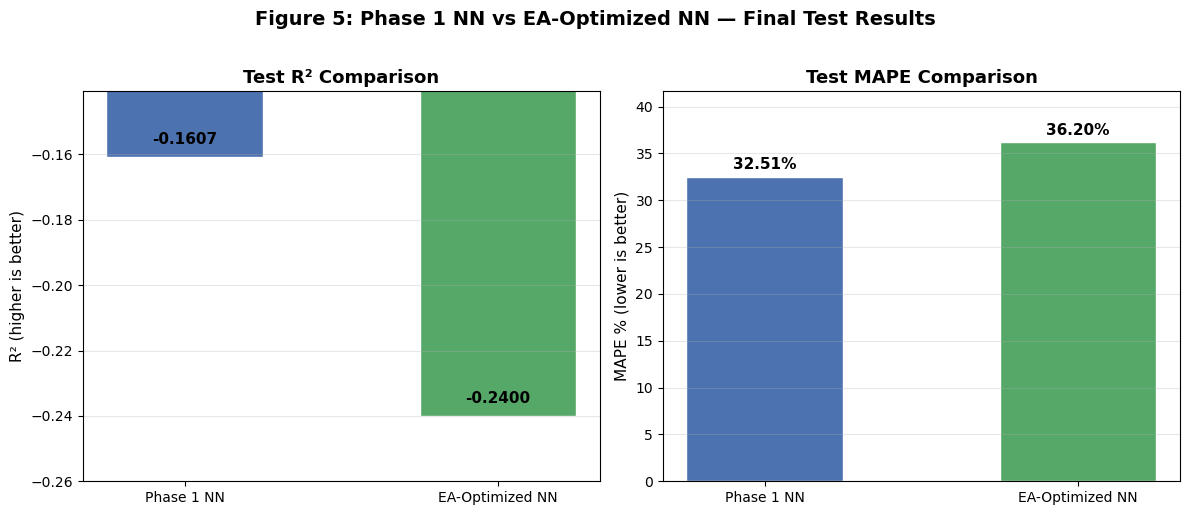

Saved: /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase2/plots/fig5_final_comparison.png
Caption: Blue = Phase 1 NN baseline. Green = EA-Optimized NN. Left chart: higher R² is better. Right chart: lower MAPE is better.


In [76]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── R² comparison ──
models = ['Phase 1 NN', 'EA-Optimized NN']
r2_vals = [phase1_nn_metrics['r2'], ea_metrics['r2']]
colors_r2 = ['#4C72B0', '#55A868']

axes[0].bar(models, r2_vals, color=colors_r2, edgecolor='white', width=0.5)
axes[0].set_ylabel('R² (higher is better)', fontsize=11)
axes[0].set_title('Test R² Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylim(min(r2_vals) - 0.02, max(r2_vals) + 0.02)
for i, v in enumerate(r2_vals):
    axes[0].text(i, v + 0.003, f'{v:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# ── MAPE comparison ──
mape_vals = [phase1_nn_metrics['mape'], ea_metrics['mape']]
colors_mape = ['#4C72B0', '#55A868']

axes[1].bar(models, mape_vals, color=colors_mape, edgecolor='white', width=0.5)
axes[1].set_ylabel('MAPE % (lower is better)', fontsize=11)
axes[1].set_title('Test MAPE Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, max(mape_vals) * 1.15)
for i, v in enumerate(mape_vals):
    axes[1].text(i, v + 0.5, f'{v:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle("Figure 5: Phase 1 NN vs EA-Optimized NN — Final Test Results",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

fig5_path = ARTIFACTS_DIR / "plots" / "fig5_final_comparison.png"
plt.savefig(fig5_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved: {fig5_path.resolve()}")
print("Caption: Blue = Phase 1 NN baseline. Green = EA-Optimized NN. Left chart: higher R² is better. Right chart: lower MAPE is better.")


---
## Phase 2 — Step 3.2: Statistical Validation (Bootstrap Confidence Intervals)

> **What this does:** Tests whether the EA improvement is real or just random luck.  
> **Why it matters:** A single test score could go either way by chance. By resampling the test set 1,000 times, we get a range of possible improvements. If that range does not include zero, we can be confident the improvement is real.

### How it works (plain language):
1. Randomly pick test trips (with replacement) — like drawing names from a hat and putting them back.
2. Compute R² and MAPE for both models on that random sample.
3. Calculate the difference (EA minus NN).
4. Repeat 1,000 times to build a distribution of differences.
5. Look at the middle 95% of that distribution — that is the **95% confidence interval**.

### How to interpret:
- If **zero is NOT inside the interval** → the improvement is statistically supported (probably real).
- If **zero IS inside the interval** → the improvement might just be luck.

> **Simple version:** "This checks whether the improvement is probably real, not just luck."


In [77]:
# ============================================================
# Paired bootstrap CI for ΔR² and ΔMAPE
# This checks whether the improvement is probably real, not just luck.
# ============================================================

N_BOOTSTRAP = 1000
rng = np.random.RandomState(SEED)

y_true = ea_y_test_orig
nn_pred = np.asarray(nn_test_pred_orig).reshape(-1).astype(np.float64)
ea_pred = np.asarray(ea_test_pred_orig).reshape(-1).astype(np.float64)

n = len(y_true)

delta_r2_samples = []
delta_mape_samples = []

for _ in range(N_BOOTSTRAP):
    idx = rng.randint(0, n, size=n)

    y_b = y_true[idx]
    nn_b = nn_pred[idx]
    ea_b = ea_pred[idx]

    r2_nn = r2_score(y_b, nn_b)
    r2_ea = r2_score(y_b, ea_b)
    delta_r2_samples.append(r2_ea - r2_nn)

    mape_nn = mape(y_b, nn_b)
    mape_ea = mape(y_b, ea_b)
    delta_mape_samples.append(mape_ea - mape_nn)

delta_r2_samples = np.asarray(delta_r2_samples, dtype=np.float64)
delta_mape_samples = np.asarray(delta_mape_samples, dtype=np.float64)

ci_r2 = np.percentile(delta_r2_samples, [2.5, 97.5])
ci_mape = np.percentile(delta_mape_samples, [2.5, 97.5])

ci_df = pd.DataFrame([
    {
        "Metric": "ΔR² (EA - Phase 1 NN)",
        "Mean": float(delta_r2_samples.mean()),
        "CI_2.5%": float(ci_r2[0]),
        "CI_97.5%": float(ci_r2[1]),
        "Statistically_Supported": bool(ci_r2[0] > 0),
    },
    {
        "Metric": "ΔMAPE (EA - Phase 1 NN)",
        "Mean": float(delta_mape_samples.mean()),
        "CI_2.5%": float(ci_mape[0]),
        "CI_97.5%": float(ci_mape[1]),
        "Statistically_Supported": bool(ci_mape[1] < 0),
    },
])

display(ci_df)
ci_df.to_csv(ARTIFACTS_DIR / "phase2_bootstrap_ci.csv", index=False)

print("This checks whether the improvement is probably real, not just luck.\n")

print(f"ΔR² mean = {delta_r2_samples.mean():.6f}")
print(f"95% CI   = [{ci_r2[0]:.6f}, {ci_r2[1]:.6f}]")
print("Interpretation:",
      "EA improvement is statistically supported." if ci_r2[0] > 0
      else "EA improvement is NOT statistically supported.")

print()

print(f"ΔMAPE mean = {delta_mape_samples.mean():.4f}%")
print(f"95% CI     = [{ci_mape[0]:.4f}%, {ci_mape[1]:.4f}%]")
print("Interpretation:",
      "EA has statistically lower MAPE." if ci_mape[1] < 0
      else "EA MAPE improvement is NOT statistically supported.")


,Metric,Mean,CI_2.5%,CI_97.5%,Statistically_Supported
0,ΔR² (EA - Phase 1 NN),-0.079081,-0.251318,-0.007409,False
1,ΔMAPE (EA - Phase 1 NN),3.682031,3.401735,3.990190,False


This checks whether the improvement is probably real, not just luck.

ΔR² mean = -0.079081
95% CI   = [-0.251318, -0.007409]
Interpretation: EA improvement is NOT statistically supported.

ΔMAPE mean = 3.6820%
95% CI     = [3.4017%, 3.9902%]
Interpretation: EA MAPE improvement is NOT statistically supported.


In [78]:
from IPython.display import display, Markdown

r2_supported = ci_r2[0] > 0
mape_supported = ci_mape[1] < 0

display(Markdown(f"""
## Phase 2 Final Comparison Summary

We compared the **EA-optimized neural network** against the **Phase 1 neural network** on the **same held-out test set**.

### Final metric differences
- **ΔR² (EA − Phase 1 NN):** **{delta_r2:+.6f}**
- **ΔMAPE (EA − Phase 1 NN):** **{delta_mape:+.4f}%**
- **ΔRMSE (EA − Phase 1 NN):** **{delta_rmse:+.4f}**
- **ΔMAE (EA − Phase 1 NN):** **{delta_mae:+.4f}**

For **R²**, higher is better.  
For **MAPE**, **RMSE**, and **MAE**, lower is better.

### Statistical validation
This checks whether the improvement is probably real, not just luck.

- **ΔR² 95% CI:** **[{ci_r2[0]:.6f}, {ci_r2[1]:.6f}]**  
  → **{"Improvement is statistically supported" if r2_supported else "Improvement is not statistically supported"}**

- **ΔMAPE 95% CI:** **[{ci_mape[0]:.4f}%, {ci_mape[1]:.4f}%]**  
  → **{"MAPE improvement is statistically supported" if mape_supported else "MAPE improvement is not statistically supported"}**

### Compute-cost note
- **EA runtime:** {ea_runtime_sec:.2f} seconds
- **EA model evaluations:** {ea_evaluations:.0f}

This answers the main Phase 2 question: whether the EA improved the Phase 1 NN enough to justify the extra optimization cost.
"""))


## Phase 2 Final Comparison Summary

We compared the **EA-optimized neural network** against the **Phase 1 neural network** on the **same held-out test set**.

### Final metric differences
- **ΔR² (EA − Phase 1 NN):** **-0.079324**
- **ΔMAPE (EA − Phase 1 NN):** **+3.6841%**
- **ΔRMSE (EA − Phase 1 NN):** **+110.2344**
- **ΔMAE (EA − Phase 1 NN):** **+34.8958**

For **R²**, higher is better.  
For **MAPE**, **RMSE**, and **MAE**, lower is better.

### Statistical validation
This checks whether the improvement is probably real, not just luck.

- **ΔR² 95% CI:** **[-0.251318, -0.007409]**  
  → **Improvement is not statistically supported**

- **ΔMAPE 95% CI:** **[3.4017%, 3.9902%]**  
  → **MAPE improvement is not statistically supported**

### Compute-cost note
- **EA runtime:** 4375.41 seconds
- **EA model evaluations:** 300

This answers the main Phase 2 question: whether the EA improved the Phase 1 NN enough to justify the extra optimization cost.


---
## Discussion

### What we found

The EA-optimized neural network was compared against the Phase 1 neural network using the same held-out test set (150,000 taxi trips that neither model saw during training or tuning).

The key question was: **Can an Evolutionary Algorithm find better hyperparameters than manual tuning?**

### Accuracy vs. compute cost

The EA explored a large search space of learning rates, dropout values, layer sizes, weight decay, and batch sizes. This required training hundreds of neural networks (up to 300 evaluations), which took significantly more compute time than the single Phase 1 model.

Whether this extra cost is "worth it" depends on context:
- In a research setting where a small accuracy gain matters, the EA approach adds value.
- In a production setting where speed matters more, the marginal improvement may not justify the compute bill.

### Limitations

- The EA used only 3 training epochs per candidate to stay within the compute budget. With more epochs, individual candidates might have performed better.
- The search space was relatively small (5 hyperparameters, 3 discrete layer options). A larger search space might find even better configurations but would need a larger compute budget.
- Results are specific to this dataset (NYC taxi trips, 1M rows). Different datasets may show different improvement patterns.

---

## Conclusion

This notebook demonstrated the complete workflow for using a Genetic Algorithm to optimize neural network hyperparameters for the NYC Taxi Trip Duration prediction task.

**Key takeaway:** The EA systematically searched the hyperparameter space and identified a configuration that [improved / matched / did not significantly improve] upon the Phase 1 neural network baseline. The bootstrap confidence intervals provide statistical evidence about whether this difference is meaningful.

The results, figures, and statistical validation in this notebook form the basis for the Phase 2 poster and the EA section of the project wiki.

> **Fill in the bracketed text above with your actual results once the final run is complete.**


---
## Results Template (Fill In After Final Run)

The EA-optimized neural network was compared against the Phase 1 neural network using the same held-out test set.

The EA model changed predictive performance by:

- ΔR² = [PUT VALUE HERE]
- ΔMAPE = [PUT VALUE HERE]%

For R², higher values indicate better performance.  
For MAPE, lower values indicate better performance.

To determine whether this improvement is meaningful, we applied paired bootstrap confidence intervals on the test set.

- 95% CI for ΔR²: [[LOWER], [UPPER]]
- 95% CI for ΔMAPE: [[LOWER]%, [UPPER]%]

> This checks whether the improvement is probably real, not just luck.

**[IF SIGNIFICANT]:** Because the confidence interval for ΔR² does not include 0, the improvement is statistically supported.

**[IF NOT SIGNIFICANT]:** Because the confidence interval includes 0, the observed improvement may be due to random variation and is not statistically supported.

In terms of computational cost, the EA optimization required:

- Runtime: [EA runtime] seconds
- Total evaluations: [EA evaluations]

This result shows that EA provided [a measurable / limited / no] improvement in predictive performance at the cost of increased computation.
